# CSE Employability Skill-Gap MLOps Project

**Google Colab-ready notebook**

Pipeline:

**Dataset → Preprocessing → ML Model → Evaluation → Saved Model → FastAPI → pytest → Docker → GitHub Actions CI/CD**

This notebook uploads your Excel/CSV dataset, lets you select the supervised-learning target, trains and evaluates classification models, saves the best pipeline, creates a FastAPI application, tests it, and generates a GitHub-ready project.


In [1]:
!pip -q install pandas numpy scikit-learn openpyxl joblib fastapi uvicorn pytest httpx requests

import os, json, shutil, zipfile, subprocess, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from google.colab import files
print("Environment ready.")


Environment ready.


## 1. Upload your dataset

In [2]:
uploaded = files.upload()
if not uploaded:
    raise ValueError("No file uploaded.")

file_name = next(iter(uploaded))
print("Uploaded:", file_name)

if file_name.lower().endswith((".xlsx", ".xls")):
    df = pd.read_excel(file_name)
elif file_name.lower().endswith(".csv"):
    df = pd.read_csv(file_name)
else:
    raise ValueError("Upload an Excel (.xlsx/.xls) or CSV file.")

print("Dataset shape:", df.shape)
display(df.head())


Saving CSE_Employability_Skill_Gap_50000_Realistic.xlsx to CSE_Employability_Skill_Gap_50000_Realistic.xlsx
Uploaded: CSE_Employability_Skill_Gap_50000_Realistic.xlsx
Dataset shape: (50000, 101)


,Student_ID,Age,Gender,Degree,Specialization,Current_Year,Semester,CGPA,Attendance_Percentage,Internal_Marks,...,LeetCode_Problems_Solved,HackerRank_Badge_Level,Certifications,Hackathons_Attended,Resume_Score,Aptitude_Score,Technical_Interview_Score,HR_Interview_Score,Mock_Interview_Score,Skill_Gap_Level
0,CSE000001,24,Female,B.Tech,AI & ML,2,3,9.78,100,79,...,0,Gold,12,7,81,51,65,54,57,Medium
1,CSE000002,20,Female,B.Tech,Cyber Security,3,5,5.99,91,100,...,604,Gold,8,9,55,67,35,35,37,High
2,CSE000003,23,Female,B.Tech,Data Science,3,5,6.82,95,45,...,612,Silver,7,6,75,81,35,35,35,Medium
3,CSE000004,19,Other,B.Tech,Cloud Computing,3,6,8.93,77,69,...,783,Silver,6,6,69,82,46,40,45,High
4,CSE000005,23,Male,B.Tech,AI & ML,3,5,9.25,70,69,...,97,Bronze,2,10,83,96,59,52,57,Medium


## 2. Inspect the dataset

In [3]:
print("Columns:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:3}. {col}")

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_count").head(30))

print("\nDuplicate rows:", df.duplicated().sum())


Columns:
  1. Student_ID
  2. Age
  3. Gender
  4. Degree
  5. Specialization
  6. Current_Year
  7. Semester
  8. CGPA
  9. Attendance_Percentage
 10. Internal_Marks
 11. External_Marks
 12. Mini_Project_Score
 13. Major_Project_Score
 14. Lab_Performance
 15. Assignment_Average
 16. Backlogs
 17. Academic_Consistency
 18. Class_Rank
 19. C_Programming
 20. C++_Programming
 21. Java
 22. Python
 23. JavaScript
 24. SQL
 25. HTML_CSS
 26. ReactJS
 27. NodeJS
 28. Programming_Logic
 29. Arrays
 30. Linked_Lists
 31. Stacks_Queues
 32. Trees
 33. Graphs
 34. Dynamic_Programming
 35. Searching_Sorting
 36. Competitive_Coding
 37. Statistics
 38. Linear_Algebra
 39. Machine_Learning
 40. Deep_Learning
 41. NLP
 42. Computer_Vision
 43. Data_Preprocessing
 44. Feature_Engineering
 45. Model_Evaluation
 46. Data_Visualization
 47. AWS
 48. Azure
 49. Google_Cloud
 50. Docker
 51. Kubernetes
 52. MLflow
 53. DVC
 54. FastAPI
 55. CI_CD
 56. Model_Monitoring
 57. MySQL
 58. PostgreSQL
 59. Mon

,dtype
Student_ID,object
Age,int64
Gender,object
Degree,object
Specialization,object
...,...
Aptitude_Score,int64
Technical_Interview_Score,int64
HR_Interview_Score,int64
Mock_Interview_Score,int64



Missing values:


,missing_count
HackerRank_Badge_Level,10083
Age,0
Gender,0
Degree,0
Student_ID,0
Current_Year,0
Semester,0
CGPA,0
Attendance_Percentage,0
Internal_Marks,0



Duplicate rows: 0


## 3. Select the ML target

For this project, the target must be the outcome representing employability, readiness, placement, or skill-gap status.

The notebook suggests likely target columns, but **you must confirm the correct target**.

Do not use `Student_ID` as the target.


In [4]:
keywords = [
    "employ", "placement", "readiness", "job", "skill_gap",
    "skill gap", "status", "outcome", "class", "target", "label"
]

possible_targets = [
    c for c in df.columns
    if any(k in str(c).lower() for k in keywords)
]

print("Possible target columns:")
print(possible_targets if possible_targets else "No obvious target found.")

TARGET_COLUMN = input("\nEnter the EXACT target column name: ").strip()

if TARGET_COLUMN not in df.columns:
    raise ValueError(f"{TARGET_COLUMN!r} is not in the dataset.")

print("\nTarget selected:", TARGET_COLUMN)
display(df[TARGET_COLUMN].value_counts(dropna=False).to_frame("count"))


Possible target columns:
['Class_Rank', 'Skill_Gap_Level']

Enter the EXACT target column name: Skill_Gap_Level

Target selected: Skill_Gap_Level


,count
Skill_Gap_Level,
High,37154
Medium,12186
Low,660


## 4. Prepare features and target

In [5]:
data = df.dropna(subset=[TARGET_COLUMN]).copy()

identifier_names = {
    "student_id", "studentid", "id", "roll_no", "roll_number",
    "registration_no", "registration_number"
}

DROP_COLUMNS = [
    c for c in data.columns
    if str(c).strip().lower() in identifier_names and c != TARGET_COLUMN
]

X = data.drop(columns=[TARGET_COLUMN] + DROP_COLUMNS).copy()
y = data[TARGET_COLUMN].astype(str).copy()

for c in X.columns:
    if X[c].dtype == bool:
        X[c] = X[c].astype(str)

if y.nunique() < 2:
    raise ValueError("Target must contain at least two classes.")

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Dropped identifiers:", DROP_COLUMNS)
print("Feature shape:", X.shape)
print("Target shape:", y.shape)


Dropped identifiers: ['Student_ID']
Feature shape: (50000, 99)
Target shape: (50000,)


## 5. Build preprocessing pipeline and split data

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

class_counts = y.value_counts()
stratify_value = y if class_counts.min() >= 2 else None

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=stratify_value
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)


Train: (40000, 99)
Test : (10000, 99)


## 6. Train and compare models

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=3000),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, random_state=42, class_weight="balanced"
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = []
trained_models = {}

for name, estimator in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", estimator)
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision_weighted": precision_score(y_test, pred, average="weighted", zero_division=0),
        "Recall_weighted": recall_score(y_test, pred, average="weighted", zero_division=0),
        "F1_weighted": f1_score(y_test, pred, average="weighted", zero_division=0)
    })
    trained_models[name] = pipe

results_df = pd.DataFrame(results).sort_values("F1_weighted", ascending=False)
display(results_df)

BEST_MODEL_NAME = results_df.iloc[0]["Model"]
BEST_PIPELINE = trained_models[BEST_MODEL_NAME]
print("Best model:", BEST_MODEL_NAME)


,Model,Accuracy,Precision_weighted,Recall_weighted,F1_weighted
2,Gradient Boosting,0.9858,0.985786,0.9858,0.985446
1,Random Forest,0.9224,0.921846,0.9224,0.916453
0,Logistic Regression,0.8661,0.861283,0.8661,0.862530


Best model: Gradient Boosting


## 7. Detailed evaluation

              precision    recall  f1-score   support

        High       0.99      0.99      0.99      7431
         Low       0.95      0.67      0.78       132
      Medium       0.96      0.98      0.97      2437

    accuracy                           0.99     10000
   macro avg       0.97      0.88      0.92     10000
weighted avg       0.99      0.99      0.99     10000



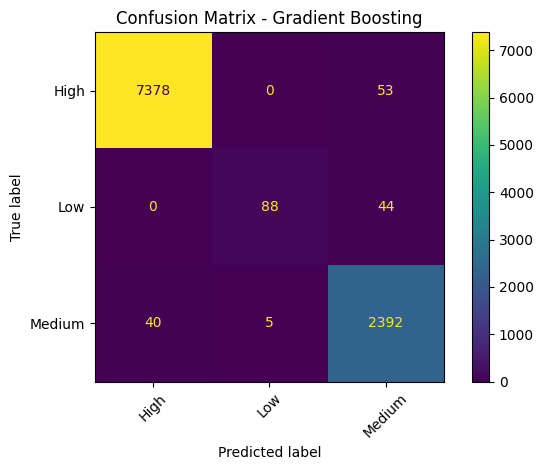

In [8]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

best_pred = BEST_PIPELINE.predict(X_test)

print(classification_report(y_test, best_pred, zero_division=0))

ConfusionMatrixDisplay.from_predictions(
    y_test, best_pred, xticks_rotation=45
)
plt.title(f"Confusion Matrix - {BEST_MODEL_NAME}")
plt.tight_layout()
plt.show()


## 8. Save the trained model

In [9]:
PROJECT_DIR = "cse_employability_mlops"

if os.path.exists(PROJECT_DIR):
    shutil.rmtree(PROJECT_DIR)

for path in [
    f"{PROJECT_DIR}/models",
    f"{PROJECT_DIR}/app",
    f"{PROJECT_DIR}/tests",
    f"{PROJECT_DIR}/.github/workflows"
]:
    os.makedirs(path, exist_ok=True)

MODEL_PATH = f"{PROJECT_DIR}/models/employability_model.joblib"
joblib.dump(BEST_PIPELINE, MODEL_PATH)

metadata = {
    "target_column": TARGET_COLUMN,
    "model_name": BEST_MODEL_NAME,
    "feature_columns": X.columns.tolist(),
    "drop_columns": DROP_COLUMNS,
    "classes": sorted(y.unique().tolist()),
    "metrics": results_df.iloc[0].to_dict()
}

with open(f"{PROJECT_DIR}/models/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, default=str)

print("Saved:", MODEL_PATH)


Saved: cse_employability_mlops/models/employability_model.joblib


## 9. Generate FastAPI application

In [11]:
sample_values = {}
for col in X.columns:
    value = X_test.iloc[0][col]
    if pd.isna(value):
        value = 0 if col in numeric_features else ""
    if isinstance(value, np.generic):
        value = value.item()
    sample_values[col] = value

api_code = (
    "from fastapi import FastAPI\n"
    "from pydantic import BaseModel, Field\n"
    "import pandas as pd\n"
    "import joblib\n"
    "import os\n\n"
    "MODEL_PATH = os.path.join(os.path.dirname(os.path.dirname(__file__)), "
    "'models', 'employability_model.joblib')\n"
    "model = joblib.load(MODEL_PATH)\n\n"
    "app = FastAPI(title='CSE Employability Skill-Gap API', version='1.0.0')\n\n"
    "class StudentInput(BaseModel):\n"
    "    data: dict = Field(..., description='Feature values using training feature names')\n\n"
    "@app.get('/')\n"
    "def root():\n"
    f"    return {{'message': 'CSE Employability Skill-Gap API is running', "
    f"'target': {TARGET_COLUMN!r}, 'model': {BEST_MODEL_NAME!r}}}\n\n"
    "@app.get('/health')\n"
    "def health():\n"
    "    return {'status': 'healthy'}\n\n"
    "@app.post('/predict')\n"
    "def predict(student: StudentInput):\n"
    "    row = pd.DataFrame([student.data])\n"
    "    missing = [c for c in model.feature_names_in_ if c not in row.columns]\n"
    "    if missing:\n"
    "        return {'error': 'Missing required features', 'missing_features': missing}\n"
    "    row = row[model.feature_names_in_]\n"
    "    prediction = model.predict(row)[0]\n"
    f"    response = {{'prediction': str(prediction), 'target': {TARGET_COLUMN!r}}}\n"
    "    if hasattr(model, 'predict_proba'):\n"
    "        probabilities = model.predict_proba(row)[0]\n"
    "        response['probabilities'] = {str(c): float(p) for c, p in zip(model.classes_, probabilities)}\n"
    "    return response\n"
)

with open(f"{PROJECT_DIR}/app/main.py", "w") as f:
    f.write(api_code)

with open(f"{PROJECT_DIR}/app/__init__.py", "w") as f:
    f.write("")

print("Created FastAPI app.")

Created FastAPI app.


## 10. Generate pytest tests

In [13]:
sample_json = json.dumps(sample_values, default=str)

test_code = (
    "import os, sys\n"
    "from fastapi.testclient import TestClient\n"
    "sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(__file__), '..')))\n"
    "from app.main import app\n\n"
    "client = TestClient(app)\n\n"
    "def test_health():\n"
    "    response = client.get('/health')\n"
    "    assert response.status_code == 200\n"
    "    assert response.json()['status'] == 'healthy'\n\n"
    "def test_root():\n"
    "    response = client.get('/')\n"
    "    assert response.status_code == 200\n"
    "    assert 'target' in response.json()\n\n"
    "def test_prediction():\n"
    f"    sample = {sample_json!r}\n"
    "    import json\n"
    "    sample = json.loads(sample)\n"
    "    response = client.post('/predict', json={'data': sample})\n"
    "    assert response.status_code == 200\n"
    "    body = response.json()\n"
    "    assert 'prediction' in body\n"
    "    assert 'target' in body\n"
)

with open(f"{PROJECT_DIR}/tests/test_api.py", "w") as f:
    f.write(test_code)

print("Created pytest tests.")

Created pytest tests.


## 11. Generate requirements, Dockerfile and .gitignore

In [15]:
requirements = (
    "pandas\n"
    "numpy\n"
    "scikit-learn\n"
    "openpyxl\n"
    "joblib\n"
    "fastapi\n"
    "uvicorn[standard]\n"
    "pydantic\n"
    "pytest\n"
    "httpx\n"
    "requests\n"
)

dockerfile = (
    "FROM python:3.13-slim\n\n"
    "WORKDIR /app\n\n"
    "COPY requirements.txt .\n"
    "RUN pip install --no-cache-dir -r requirements.txt\n\n"
    "COPY . .\n\n"
    "EXPOSE 8000\n\n"
    "CMD ['uvicorn', 'app.main:app', '--host', '0.0.0.0', '--port', '8000']\n"
)

gitignore = "__pycache__/\n*.pyc\n.ipynb_checkpoints/\n.env\n.venv/\nvenv/\n"

for name, content in [
    ("requirements.txt", requirements),
    ("Dockerfile", dockerfile),
    (".gitignore", gitignore)
]:
    with open(f"{PROJECT_DIR}/{name}", "w") as f:
        f.write(content)

print("Created project configuration files.")

Created project configuration files.


## 12. Generate combined GitHub Actions CI/CD

In [17]:
cicd = (
    "name: CSE Employability ML CI/CD\n\n"
    "on:\n"
    "  push:\n"
    "    branches: [main]\n"
    "  pull_request:\n"
    "    branches: [main]\n"
    "  workflow_dispatch:\n\n"
    "permissions:\n"
    "  contents: read\n\n"
    "jobs:\n\n"
    "  test:\n"
    "    name: CI - Test ML Application\n"
    "    runs-on: ubuntu-latest\n"
    "    steps:\n"
    "      - name: Checkout source code\n"
    "        uses: actions/checkout@v4\n"
    "      - name: Set up Python\n"
    "        uses: actions/setup-python@v5\n"
    "        with:\n"
    "          python-version: '3.13'\n"
    "      - name: Install dependencies\n"
    "        run: pip install -r requirements.txt\n"
    "      - name: Run automated tests\n"
    "        run: pytest -v\n\n"
    "  docker:\n"
    "    name: CD - Build Docker Image\n"
    "    needs: test\n"
    "    runs-on: ubuntu-latest\n"
    "    steps:\n"
    "      - name: Checkout source code\n"
    "        uses: actions/checkout@v4\n"
    "      - name: Build Docker image\n"
    "        run: docker build -t cse-employability-mlops:latest .\n"
    "      - name: Verify Docker image\n"
    "        run: docker images cse-employability-mlops\n"
)

with open(f"{PROJECT_DIR}/.github/workflows/cicd.yml", "w") as f:
    f.write(cicd)

print(cicd)

name: CSE Employability ML CI/CD

on:
  push:
    branches: [main]
  pull_request:
    branches: [main]
  workflow_dispatch:

permissions:
  contents: read

jobs:

  test:
    name: CI - Test ML Application
    runs-on: ubuntu-latest
    steps:
      - name: Checkout source code
        uses: actions/checkout@v4
      - name: Set up Python
        uses: actions/setup-python@v5
        with:
          python-version: '3.13'
      - name: Install dependencies
        run: pip install -r requirements.txt
      - name: Run automated tests
        run: pytest -v

  docker:
    name: CD - Build Docker Image
    needs: test
    runs-on: ubuntu-latest
    steps:
      - name: Checkout source code
        uses: actions/checkout@v4
      - name: Build Docker image
        run: docker build -t cse-employability-mlops:latest .
      - name: Verify Docker image
        run: docker images cse-employability-mlops



## 13. Generate README

In [18]:
readme = (
    "# CSE Employability Skill-Gap MLOps Project\n\n"
    "## Problem\n"
    "Curriculum-Industry Skill Alignment Decision Framework for Identifying Employability Skill Gaps in CSE Graduates.\n\n"
    f"## ML target\n`{TARGET_COLUMN}`\n\n"
    f"## Selected model\n`{BEST_MODEL_NAME}`\n\n"
    "## Pipeline\n"
    "Dataset -> Preprocessing -> ML Training -> Evaluation -> FastAPI -> pytest -> Docker -> GitHub Actions CI/CD\n\n"
    "## API\n"
    "Run `pip install -r requirements.txt` and then "
    "`uvicorn app.main:app --host 0.0.0.0 --port 8000`.\n\n"
    "## CI/CD\n"
    "Tests run first. The Docker/CD job uses `needs: test`, so it only runs after CI succeeds.\n"
)

with open(f"{PROJECT_DIR}/README.md", "w") as f:
    f.write(readme)

print(readme)


# CSE Employability Skill-Gap MLOps Project

## Problem
Curriculum-Industry Skill Alignment Decision Framework for Identifying Employability Skill Gaps in CSE Graduates.

## ML target
`Skill_Gap_Level`

## Selected model
`Gradient Boosting`

## Pipeline
Dataset -> Preprocessing -> ML Training -> Evaluation -> FastAPI -> pytest -> Docker -> GitHub Actions CI/CD

## API
Run `pip install -r requirements.txt` and then `uvicorn app.main:app --host 0.0.0.0 --port 8000`.

## CI/CD
Tests run first. The Docker/CD job uses `needs: test`, so it only runs after CI succeeds.



## 14. Run the generated tests in Colab

In [19]:
!pip -q install -r cse_employability_mlops/requirements.txt
!cd cse_employability_mlops && pytest -v


============================= test session starts ==============================
platform linux -- Python 3.13.15, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content/cse_employability_mlops
plugins: anyio-4.15.1, langsmith-0.12.5, typeguard-4.6.0
collected 3 items                                                              

tests/test_api.py::test_health PASSED                                    [ 33%]
tests/test_api.py::test_root PASSED                                      [ 66%]
tests/test_api.py::test_prediction PASSED                                [100%]

============================== 3 passed in 1.59s ===============================


## 15. Test the FastAPI prediction endpoint in Colab

In [21]:
server = subprocess.Popen(
    ["uvicorn", "app.main:app", "--host", "127.0.0.1", "--port", "8000"],
    cwd=PROJECT_DIR,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

time.sleep(4)

try:
    import requests

    # Check if the server is still running
    poll = server.poll()
    if poll is not None:
        stdout, _ = server.communicate()
        print("Server failed to start. Logs:")
        print(stdout)
        raise RuntimeError("Uvicorn server exited prematurely.")

    health = requests.get("http://127.0.0.1:8000/health", timeout=10)
    print("Health:", health.status_code, health.json())

    prediction = requests.post(
        "http://127.0.0.1:8000/predict",
        json={"data": sample_values},
        timeout=20
    )
    print("Prediction status:", prediction.status_code)
    print("Prediction:", prediction.json())
except Exception as e:
    print("Request Error:", e)
    # If connection fails, output server logs to diagnose
    if server.poll() is None:
        server.terminate()
    stdout, _ = server.communicate()
    print("\n--- Server Stdout/Stderr Output ---")
    print(stdout)
finally:
    if server.poll() is None:
        server.terminate()
        try:
            server.wait(timeout=5)
        except:
            server.kill()

Health: 200 {'status': 'healthy'}
Prediction status: 200
Prediction: {'prediction': 'Medium', 'target': 'Skill_Gap_Level', 'probabilities': {'High': 0.004091301332787393, 'Low': 0.00012190120939124151, 'Medium': 0.9957867974578214}}


## 16. Create and download the GitHub-ready ZIP

In [22]:
zip_path = f"{PROJECT_DIR}.zip"

if os.path.exists(zip_path):
    os.remove(zip_path)

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for root, dirs, file_names in os.walk(PROJECT_DIR):
        for name in file_names:
            full = os.path.join(root, name)
            arc = os.path.relpath(full, os.path.dirname(PROJECT_DIR))
            z.write(full, arc)

print("Created:", zip_path)
files.download(zip_path)


Created: cse_employability_mlops.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Final GitHub procedure

1. Download the ZIP produced above.
2. Extract it.
3. Create a GitHub repository.
4. Upload the extracted project.
5. Use `main` as the branch.
6. Open **Actions**.
7. Verify **CSE Employability ML CI/CD**.
8. Successful flow:

**CI tests pass → Docker/CD job runs**

9. For the demonstration, intentionally break a test:

**CI fails → Docker/CD job is skipped**

10. Fix the test and push again:

**CI passes → Docker/CD job runs**
